# Probablisitic Forecasts using NGBoost

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score, make_scorer
from sklearn.multioutput import MultiOutputRegressor
from ngboost import NGBRegressor, scores
from ngboost.distns import Normal, LogNormal, Exponential
from skforecast.metrics import crps_from_quantiles
from sktime.performance_metrics.forecasting.probabilistic import CRPS
from scipy.stats import norm
from skopt.space import Real, Integer
from skopt import BayesSearchCV
from skopt.plots import plot_objective, plot_convergence
import joblib
import seaborn as sns
import shap

c:\Users\ABHIROOP\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings
warnings.filterwarnings("ignore")

## Read Data

In [3]:
data = pd.read_csv('../Data/Kolkata-6hr.csv', parse_dates=['time'], index_col='time')
data.head()

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),dew_point_2m (°C),wind_speed_10m (km/h),is_day ()
time,,,,,,,
1995-01-01 00:00:00,15.3,81,0.0,1015.8,12.0,10.5,0
1995-01-01 06:00:00,23.2,42,0.0,1017.0,9.6,8.7,1
1995-01-01 12:00:00,20.8,51,0.0,1014.4,10.3,6.7,0
1995-01-01 18:00:00,15.0,73,0.0,1015.8,10.2,6.9,0
1995-01-02 00:00:00,11.6,79,0.0,1015.5,8.2,7.6,0


In [4]:
data.max()

temperature_2m (°C)           42.2
relative_humidity_2m (%)     100.0
rain (mm)                     96.7
surface_pressure (hPa)      1021.5
dew_point_2m (°C)             29.8
wind_speed_10m (km/h)         60.7
is_day ()                      1.0
dtype: float64

In [5]:
data.min()

temperature_2m (°C)           8.2
relative_humidity_2m (%)     12.0
rain (mm)                     0.0
surface_pressure (hPa)      974.0
dew_point_2m (°C)             0.6
wind_speed_10m (km/h)         0.0
is_day ()                     0.0
dtype: float64

In [6]:
data.describe()

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),dew_point_2m (°C),wind_speed_10m (km/h),is_day ()
count,43832.000000,43832.000000,43832.000000,43832.000000,43832.000000,43832.000000,43832.000000
mean,25.855101,76.788533,1.137306,1007.018502,20.871838,8.828593,0.535636
std,5.308843,18.648173,3.313909,6.190607,5.542917,4.265293,0.498734
min,8.200000,12.000000,0.000000,974.000000,0.600000,0.000000,0.000000
25%,23.200000,64.000000,0.000000,1002.100000,16.200000,6.000000,0.000000
50%,26.500000,83.000000,0.000000,1007.200000,23.600000,8.000000,1.000000
75%,29.100000,92.000000,0.500000,1012.300000,25.400000,10.900000,1.000000
max,42.200000,100.000000,96.700000,1021.500000,29.800000,60.700000,1.000000


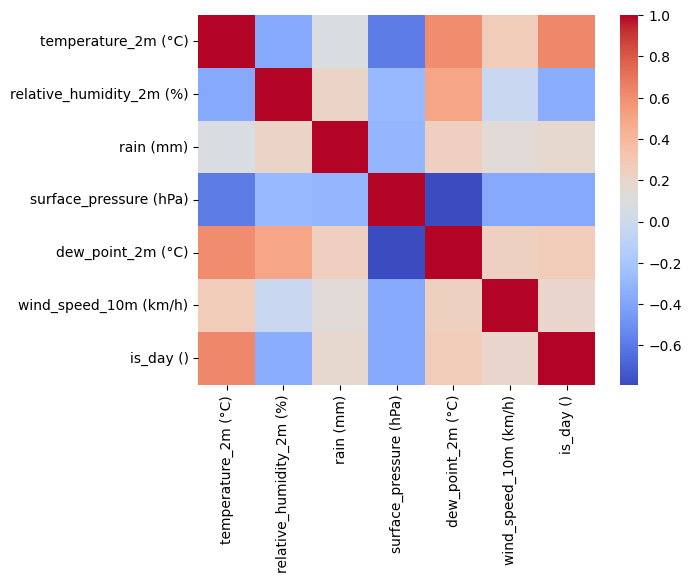

In [7]:
dataplot = sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', annot=False)

In [8]:
train = data.loc[:'2018-12-31 23:59:59']
test = data.loc['2019-01-01 00:00:00':]

train_stats = train.agg(['min', 'max', 'mean', 'std', 'median', 'skew', 'kurt'])
test_stats  = test.agg(['min', 'max', 'mean', 'std', 'median', 'skew', 'kurt'])
overall_stats = data.agg(['min', 'max', 'mean', 'std', 'median', 'skew', 'kurt'])

In [9]:
train_stats

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),dew_point_2m (°C),wind_speed_10m (km/h),is_day ()
min,8.200000,12.000000,0.000000,974.000000,0.600000,0.000000,0.000000
max,41.200000,100.000000,96.700000,1021.500000,28.700000,44.500000,1.000000
mean,25.855769,76.400468,1.090301,1006.936496,20.769390,8.769852,0.535706
std,5.305241,18.916352,3.226857,6.220666,5.585880,4.164504,0.498731
median,26.500000,82.000000,0.000000,1007.000000,23.500000,8.000000,1.000000
skew,-0.549076,-0.841616,7.488187,-0.139180,-0.768651,1.036858,-0.143196
kurt,0.337899,-0.386183,102.706250,-0.914529,-0.725229,1.909210,-1.979608


In [21]:
train_stats.T

,min,max,mean,std,median,skew,kurt
temperature_2m (°C),8.2,41.2,25.855769,5.305241,26.5,-0.549076,0.337899
relative_humidity_2m (%),12.0,100.0,76.400468,18.916352,82.0,-0.841616,-0.386183
rain (mm),0.0,96.7,1.090301,3.226857,0.0,7.488187,102.706250
surface_pressure (hPa),974.0,1021.5,1006.936496,6.220666,1007.0,-0.139180,-0.914529
dew_point_2m (°C),0.6,28.7,20.769390,5.585880,23.5,-0.768651,-0.725229
wind_speed_10m (km/h),0.0,44.5,8.769852,4.164504,8.0,1.036858,1.909210
is_day (),0.0,1.0,0.535706,0.498731,1.0,-0.143196,-1.979608


In [10]:
test_stats

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),dew_point_2m (°C),wind_speed_10m (km/h),is_day ()
min,9.900000,15.000000,0.000000,978.800000,3.800000,0.000000,0.000000
max,42.200000,100.000000,67.000000,1020.500000,29.800000,60.700000,1.000000
mean,25.852429,78.340443,1.325285,1007.346453,21.281535,9.063504,0.535356
std,5.323525,17.449717,3.635421,6.058175,5.348396,4.639382,0.498777
median,26.600000,84.000000,0.000000,1007.600000,23.800000,8.200000,1.000000
skew,-0.513415,-0.967749,5.192367,-0.193505,-0.706993,1.431104,-0.141803
kurt,0.132932,0.124387,42.409238,-0.743774,-0.817811,4.777196,-1.980344


In [22]:
test_stats.T

,min,max,mean,std,median,skew,kurt
temperature_2m (°C),9.9,42.2,25.852429,5.323525,26.6,-0.513415,0.132932
relative_humidity_2m (%),15.0,100.0,78.340443,17.449717,84.0,-0.967749,0.124387
rain (mm),0.0,67.0,1.325285,3.635421,0.0,5.192367,42.409238
surface_pressure (hPa),978.8,1020.5,1007.346453,6.058175,1007.6,-0.193505,-0.743774
dew_point_2m (°C),3.8,29.8,21.281535,5.348396,23.8,-0.706993,-0.817811
wind_speed_10m (km/h),0.0,60.7,9.063504,4.639382,8.2,1.431104,4.777196
is_day (),0.0,1.0,0.535356,0.498777,1.0,-0.141803,-1.980344


In [11]:
overall_stats

,temperature_2m (°C),relative_humidity_2m (%),rain (mm),surface_pressure (hPa),dew_point_2m (°C),wind_speed_10m (km/h),is_day ()
min,8.200000,12.000000,0.000000,974.000000,0.600000,0.000000,0.000000
max,42.200000,100.000000,96.700000,1021.500000,29.800000,60.700000,1.000000
mean,25.855101,76.788533,1.137306,1007.018502,20.871838,8.828593,0.535636
std,5.308843,18.648173,3.313909,6.190607,5.542917,4.265293,0.498734
median,26.500000,83.000000,0.000000,1007.200000,23.600000,8.000000,1.000000
skew,-0.541869,-0.868838,6.910002,-0.150863,-0.759985,1.147932,-0.142913
kurt,0.296305,-0.292067,86.167183,-0.882893,-0.728180,2.789059,-1.979666


In [23]:
overall_stats.T

,min,max,mean,std,median,skew,kurt
temperature_2m (°C),8.2,42.2,25.855101,5.308843,26.5,-0.541869,0.296305
relative_humidity_2m (%),12.0,100.0,76.788533,18.648173,83.0,-0.868838,-0.292067
rain (mm),0.0,96.7,1.137306,3.313909,0.0,6.910002,86.167183
surface_pressure (hPa),974.0,1021.5,1007.018502,6.190607,1007.2,-0.150863,-0.882893
dew_point_2m (°C),0.6,29.8,20.871838,5.542917,23.6,-0.759985,-0.728180
wind_speed_10m (km/h),0.0,60.7,8.828593,4.265293,8.0,1.147932,2.789059
is_day (),0.0,1.0,0.535636,0.498734,1.0,-0.142913,-1.979666


## Feature Engineering

In [12]:
cols = list(data.columns)
cols1 = [_ + '-1' for _ in cols]
col1 = dict(map(lambda i,j : (i,j) , cols,cols1))
cols2 = [_ + '-2' for _ in cols]
col2 = dict(map(lambda i,j : (i,j) , cols,cols2))
cols3 = [_ + '-3' for _ in cols]
col3 = dict(map(lambda i,j : (i,j) , cols,cols3))
cols4 = [_ + '-4' for _ in cols]
col4 = dict(map(lambda i,j : (i,j) , cols,cols4))
cols5 = [_ + '-5' for _ in cols]
col5 = dict(map(lambda i,j : (i,j) , cols,cols5))
cols6 = [_ + '-6' for _ in cols]
col6 = dict(map(lambda i,j : (i,j) , cols,cols6))
cols7 = [_ + '-7' for _ in cols]
col7 = dict(map(lambda i,j : (i,j) , cols,cols7))
cols8 = [_ + '-8' for _ in cols]
col8 = dict(map(lambda i,j : (i,j) , cols,cols8))
cols9 = [_ + '-9' for _ in cols]
col9 = dict(map(lambda i,j : (i,j) , cols,cols9))
cols10 = [_ + '-10' for _ in cols]
col10 = dict(map(lambda i,j : (i,j) , cols,cols10))
cols11 = [_ + '-11' for _ in cols]
col11 = dict(map(lambda i,j : (i,j) , cols,cols11))
cols12 = [_ + '-12' for _ in cols]
col12 = dict(map(lambda i,j : (i,j) , cols,cols12))

In [13]:
s1 = data[:].shift(+1).rename(columns=col1)
s2 = data[:].shift(+2).rename(columns=col2)
s3 = data[:].shift(+3).rename(columns=col3)
s4 = data[:].shift(+4).rename(columns=col4)
s5 = data[:].shift(+5).rename(columns=col5)
s6 = data[:].shift(+6).rename(columns=col6)
s7 = data[:].shift(+7).rename(columns=col7)
s8 = data[:].shift(+8).rename(columns=col8)
s9 = data[:].shift(+9).rename(columns=col9)
s10 = data[:].shift(+10).rename(columns=col10)
s11 = data[:].shift(+11).rename(columns=col11)
s12 = data[:].shift(+12).rename(columns=col12)
X = pd.concat([s1, s2, s3, s4, s5, s6, s7, s8, s9, s10, s11, s12], axis=1)
X.head()

,temperature_2m (°C)-1,relative_humidity_2m (%)-1,rain (mm)-1,surface_pressure (hPa)-1,dew_point_2m (°C)-1,wind_speed_10m (km/h)-1,is_day ()-1,temperature_2m (°C)-2,relative_humidity_2m (%)-2,rain (mm)-2,...,dew_point_2m (°C)-11,wind_speed_10m (km/h)-11,is_day ()-11,temperature_2m (°C)-12,relative_humidity_2m (%)-12,rain (mm)-12,surface_pressure (hPa)-12,dew_point_2m (°C)-12,wind_speed_10m (km/h)-12,is_day ()-12
time,,,,,,,,,,,,,,,,,,,,,
1995-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-01 06:00:00,15.3,81.0,0.0,1015.8,12.0,10.5,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-01 12:00:00,23.2,42.0,0.0,1017.0,9.6,8.7,1.0,15.3,81.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-01 18:00:00,20.8,51.0,0.0,1014.4,10.3,6.7,0.0,23.2,42.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-02 00:00:00,15.0,73.0,0.0,1015.8,10.2,6.9,0.0,20.8,51.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
X.dropna(inplace=True)
X.head()

,temperature_2m (°C)-1,relative_humidity_2m (%)-1,rain (mm)-1,surface_pressure (hPa)-1,dew_point_2m (°C)-1,wind_speed_10m (km/h)-1,is_day ()-1,temperature_2m (°C)-2,relative_humidity_2m (%)-2,rain (mm)-2,...,dew_point_2m (°C)-11,wind_speed_10m (km/h)-11,is_day ()-11,temperature_2m (°C)-12,relative_humidity_2m (%)-12,rain (mm)-12,surface_pressure (hPa)-12,dew_point_2m (°C)-12,wind_speed_10m (km/h)-12,is_day ()-12
time,,,,,,,,,,,,,,,,,,,,,
1995-01-04 00:00:00,13.7,69.0,0.0,1016.1,8.1,9.3,0.0,20.1,42.0,0.0,...,9.6,8.7,1.0,15.3,81.0,0.0,1015.8,12.0,10.5,0.0
1995-01-04 06:00:00,10.6,86.0,0.0,1016.4,8.4,7.9,0.0,13.7,69.0,0.0,...,10.3,6.7,0.0,23.2,42.0,0.0,1017.0,9.6,8.7,1.0
1995-01-04 12:00:00,23.4,32.0,0.0,1017.8,5.8,7.9,1.0,10.6,86.0,0.0,...,10.2,6.9,0.0,20.8,51.0,0.0,1014.4,10.3,6.7,0.0
1995-01-04 18:00:00,20.7,42.0,0.0,1015.1,7.4,9.7,0.0,23.4,32.0,0.0,...,8.2,7.6,0.0,15.0,73.0,0.0,1015.8,10.2,6.9,0.0
1995-01-05 00:00:00,14.3,71.0,0.0,1017.0,9.1,10.4,0.0,20.7,42.0,0.0,...,5.3,6.8,1.0,11.6,79.0,0.0,1015.5,8.2,7.6,0.0


In [15]:
X=X.iloc[::4]

In [16]:
X['Day of Year'] = X.index.day_of_year
X['Year'] = X.index.year
X['Month'] = X.index.month
#X["is_monsoon"] = X.index.month.isin([6, 7, 8, 9]).astype(int)
#X['is_heatwave'] = (
#    (X["temperature_2m (°C)-3"] >= 40) &
#    (X["temperature_2m (°C)-7"] >= 40) &
#    (X["temperature_2m (°C)-11"] >= 40)
#)
X.head()

,temperature_2m (°C)-1,relative_humidity_2m (%)-1,rain (mm)-1,surface_pressure (hPa)-1,dew_point_2m (°C)-1,wind_speed_10m (km/h)-1,is_day ()-1,temperature_2m (°C)-2,relative_humidity_2m (%)-2,rain (mm)-2,...,temperature_2m (°C)-12,relative_humidity_2m (%)-12,rain (mm)-12,surface_pressure (hPa)-12,dew_point_2m (°C)-12,wind_speed_10m (km/h)-12,is_day ()-12,Day of Year,Year,Month
time,,,,,,,,,,,,,,,,,,,,,
1995-01-04,13.7,69.0,0.0,1016.1,8.1,9.3,0.0,20.1,42.0,0.0,...,15.3,81.0,0.0,1015.8,12.0,10.5,0.0,4,1995,1
1995-01-05,14.3,71.0,0.0,1017.0,9.1,10.4,0.0,20.7,42.0,0.0,...,11.6,79.0,0.0,1015.5,8.2,7.6,0.0,5,1995,1
1995-01-06,15.3,76.0,0.0,1017.9,11.1,9.2,0.0,21.8,47.0,0.0,...,10.2,88.0,0.0,1015.9,8.3,8.3,0.0,6,1995,1
1995-01-07,18.0,67.0,0.0,1018.9,11.8,6.9,0.0,22.4,50.0,0.0,...,10.6,86.0,0.0,1016.4,8.4,7.9,0.0,7,1995,1
1995-01-08,18.2,71.0,0.0,1018.2,13.0,7.6,0.0,23.8,49.0,0.0,...,11.3,89.0,0.0,1017.6,9.6,7.8,0.0,8,1995,1


In [17]:
X['day_sin'] = np.sin(2 * np.pi * X['Day of Year'] / 365)
X['day_cos'] = np.cos(2 * np.pi * X['Day of Year'] / 365)

X['month_sin'] = np.sin(2 * np.pi * X['Month'] / 12)
X['month_sin'] = np.sin(2 * np.pi * X['Month'] / 12)

X.drop(['Day of Year', 'Month'], axis=1, inplace=True)
X.head()

,temperature_2m (°C)-1,relative_humidity_2m (%)-1,rain (mm)-1,surface_pressure (hPa)-1,dew_point_2m (°C)-1,wind_speed_10m (km/h)-1,is_day ()-1,temperature_2m (°C)-2,relative_humidity_2m (%)-2,rain (mm)-2,...,relative_humidity_2m (%)-12,rain (mm)-12,surface_pressure (hPa)-12,dew_point_2m (°C)-12,wind_speed_10m (km/h)-12,is_day ()-12,Year,day_sin,day_cos,month_sin
time,,,,,,,,,,,,,,,,,,,,,
1995-01-04,13.7,69.0,0.0,1016.1,8.1,9.3,0.0,20.1,42.0,0.0,...,81.0,0.0,1015.8,12.0,10.5,0.0,1995,0.068802,0.997630,0.5
1995-01-05,14.3,71.0,0.0,1017.0,9.1,10.4,0.0,20.7,42.0,0.0,...,79.0,0.0,1015.5,8.2,7.6,0.0,1995,0.085965,0.996298,0.5
1995-01-06,15.3,76.0,0.0,1017.9,11.1,9.2,0.0,21.8,47.0,0.0,...,88.0,0.0,1015.9,8.3,8.3,0.0,1995,0.103102,0.994671,0.5
1995-01-07,18.0,67.0,0.0,1018.9,11.8,6.9,0.0,22.4,50.0,0.0,...,86.0,0.0,1016.4,8.4,7.9,0.0,1995,0.120208,0.992749,0.5
1995-01-08,18.2,71.0,0.0,1018.2,13.0,7.6,0.0,23.8,49.0,0.0,...,89.0,0.0,1017.6,9.6,7.8,0.0,1995,0.137279,0.990532,0.5


In [18]:
data_Y = data['temperature_2m (°C)'].iloc[12:]

s1 = data_Y[:]
s2 = data_Y[:].shift(-1).rename('temperature_2m (°C)+1')
s3 = data_Y[:].shift(-2).rename('temperature_2m (°C)+2')
s4 = data_Y[:].shift(-3).rename('temperature_2m (°C)+3')

Y = pd.concat([s1, s2, s3, s4], axis=1)
Y = Y.iloc[::4]

Y.head()

,temperature_2m (°C),temperature_2m (°C)+1,temperature_2m (°C)+2,temperature_2m (°C)+3
time,,,,
1995-01-04,10.6,23.4,20.7,14.3
1995-01-05,11.3,24.5,21.8,15.3
1995-01-06,13.4,24.5,22.4,18.0
1995-01-07,16.7,25.9,23.8,18.2
1995-01-08,16.5,22.8,24.6,19.1


In [19]:
X.shape, Y.shape

((10955, 88), (10955, 4))

In [20]:
X.index[-1]

Timestamp('2024-12-31 00:00:00')

## Train-Test Split

In [21]:
train_start = '1995-01-01 00:00:00'
train_end = '2018-12-31 18:00:00'
print(f"Training done from {train_start} to {train_end}")

test_start = '2019-01-01 00:00:00'
test_end = '2024-12-31 18:00:00'
print(f"Testing done from {test_start} to {test_end}")

Training done from 1995-01-01 00:00:00 to 2018-12-31 18:00:00
Testing done from 2019-01-01 00:00:00 to 2024-12-31 18:00:00


In [22]:
X_train = X.loc[train_start:train_end]
y_train = Y.loc[train_start:train_end]

X_test = X.loc[test_start:test_end]
y_test = Y.loc[test_start:test_end]

In [23]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8763, 88), (8763, 4), (2192, 88), (2192, 4))

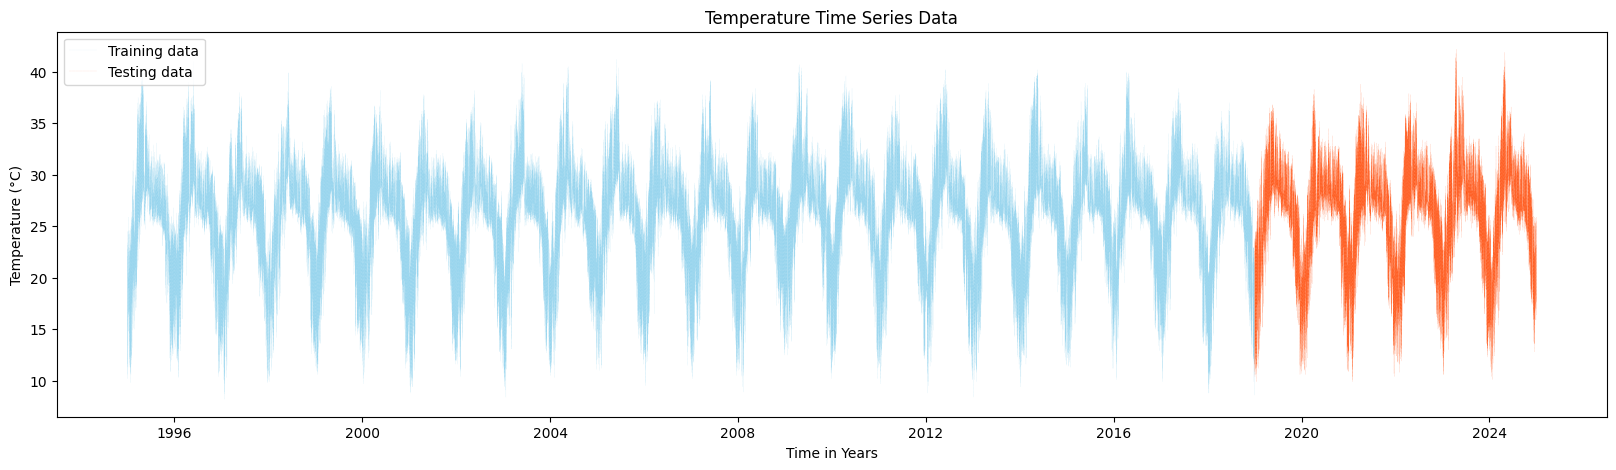

In [24]:
fig = plt.figure(figsize=(20,5))
plt.plot(data.loc[train_start:train_end].index, data['temperature_2m (°C)'].loc[train_start:train_end], label='Training data', color='skyblue', linewidth=0.1, linestyle=':')
plt.plot(data.loc[test_start:test_end].index, data['temperature_2m (°C)'].loc[test_start:test_end], label='Testing data', color='orangered', linewidth=0.1, linestyle=':')
plt.xlabel('Time in Years')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Time Series Data')
plt.legend(loc = 'upper left')
plt.show()

## Scaling

In [25]:
StandardScaler_X = StandardScaler()
X_train_scaled = StandardScaler_X.fit_transform(X_train)
X_test_scaled = StandardScaler_X.transform(X_test)

StandardScaler_Y = StandardScaler()
y_train_scaled = StandardScaler_Y.fit_transform(y_train)
y_test_scaled = StandardScaler_Y.transform(y_test)

In [26]:
def willmott_index(y_true, y_pred):
    """
    Calculates the Willmott Index (WI).
    """
    numerator = np.sum((y_pred - y_true)**2)
    denominator = np.sum((np.abs(y_true - np.mean(y_true)) + np.abs(y_pred - np.mean(y_true))) ** 2)
    return 1-(numerator / denominator)

def percent_bias(y_true, y_pred):
    """
    Calculates the Percent Bias (PBIAS).
    """
    return 100 * np.sum(y_pred - y_true) / np.sum(y_true)

## Model Training

In [27]:
base_dt = DecisionTreeRegressor(max_depth=4, max_features=1.0, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = base_dt, Score= scores.CRPScore, n_estimators=200, learning_rate=0.05, early_stopping_rounds=10, random_state=1)
multi_gb = MultiOutputRegressor(base_gb)
multi_gb.fit(X_train_scaled, y_train_scaled)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5754 val_loss=0.5378 scale=1.0000 norm=1.1982
[iter 100] loss=0.0636 val_loss=0.0769 scale=0.2500 norm=1.9198
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5659 val_loss=0.5281 scale=1.0000 norm=1.2013
[iter 100] loss=0.1482 val_loss=0.1651 scale=0.0078 norm=0.0296
== Early stopping achieved.
== Best iteration / VAL118 (val_loss=0.1648)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5648 val_loss=0.5355 scale=1.0000 norm=1.2037
[iter 100] loss=0.1548 val_loss=0.1773 s

,estimator,NGBRegressor(...0x1C8D73F9B40)
,n_jobs,None
,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,20
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,1.0
,random_state,None
,max_leaf_nodes,None


## Bayesian Optimization

In [28]:
tscv_inner = TimeSeriesSplit(n_splits=4)  
tscv_outer = TimeSeriesSplit(n_splits=4) 

def rmse_multioutput(y_true, y_pred):
    return root_mean_squared_error( y_true, y_pred, squared=False)

rmse_scorer = make_scorer(rmse_multioutput, greater_is_better=False)

base_dt = DecisionTreeRegressor(max_depth=4, max_features=1.0, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = base_dt, Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)
multi_gb = MultiOutputRegressor(base_gb)

params_space = {          
    "estimator__learning_rate": Real(0.01, 0.06, prior='log-uniform'),
    "estimator__col_sample": Real(0.3, 0.9),
    "estimator__minibatch_frac": Real(0.5, 1.0),    
    "estimator__Dist:" : [Normal, LogNormal, Exponential] 
}

bayes = BayesSearchCV(
    estimator=multi_gb,
    search_spaces=params_space,
    n_iter=10,
    cv=tscv_inner,
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1,
    random_state=1,
    verbose=1
)

bayes.fit(X_train_scaled, y_train_scaled)
print("Best Parameters:", bayes.best_params_)
print("Best Score (neg MSE):", bayes.best_score_)

Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
Fitting 4 folds for each of 1 candidates, totalling 4 fits
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5761 val_loss=0.5431 scale=1.0000 norm=1.1993
[iter 100] loss=0.0671 val_loss=0.0788 scale=0.1250 norm=0.9445
== Early stopping achieved.
== Best iteration / VAL170 (val_loss=0.0763)
early_stopping_round

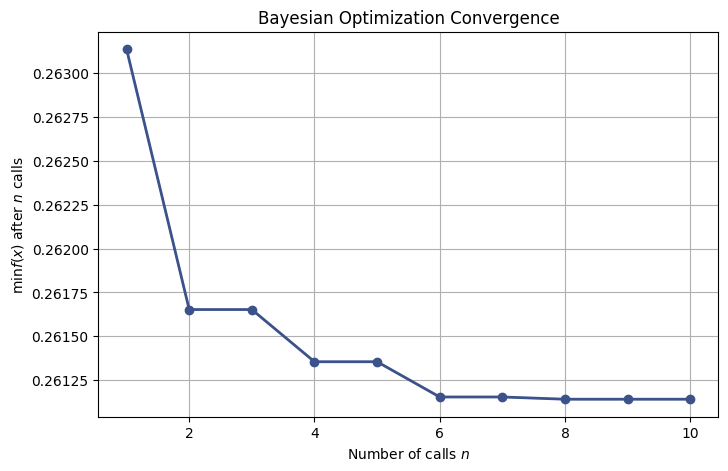

In [29]:
plt.figure(figsize=(8, 5))
plot_convergence(bayes.optimizer_results_)
plt.title("Bayesian Optimization Convergence")
plt.show()

### Training with Optimized hyperparamters

In [30]:
dt = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20)
base_gb = NGBRegressor(Base = DecisionTreeRegressor(max_depth=4, min_samples_split = 20, min_samples_leaf = 20),
                       Dist= bayes.best_params_['estimator__Dist:'], 
                       learning_rate= bayes.best_params_['estimator__learning_rate'], 
                       n_estimators= 200,
                       col_sample= bayes.best_params_['estimator__col_sample'],
                       minibatch_frac= bayes.best_params_['estimator__minibatch_frac'],
                       Score= scores.CRPScore, early_stopping_rounds=10, random_state=1)
multi_gb = MultiOutputRegressor(base_gb)
multi_gb.fit(X_train_scaled, y_train_scaled)

early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5761 val_loss=0.5431 scale=1.0000 norm=1.1993
[iter 100] loss=0.0671 val_loss=0.0788 scale=0.1250 norm=0.9445
== Early stopping achieved.
== Best iteration / VAL170 (val_loss=0.0763)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5675 val_loss=0.5323 scale=1.0000 norm=1.2028
[iter 100] loss=0.1481 val_loss=0.1662 scale=0.2500 norm=0.9091
== Early stopping achieved.
== Best iteration / VAL151 (val_loss=0.1651)
early_stopping_rounds is set to 10 but no validation set is provided creating val set with 0.1 of the training data
Creating validation set without sample weight similar to the training data
[iter 0] loss=0.5671 val_loss

,estimator,NGBRegressor(...0x1C8D73FB540)
,n_jobs,None
,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,20
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None


In [31]:
joblib.dump(multi_gb, '../Models/ngboost_model.pkl')

['../Models/ngboost_model.pkl']

## Predictions 
With optimized model

In [32]:
dist_1 = multi_gb.estimators_[0].pred_dist(X_test_scaled)
dist_2 = multi_gb.estimators_[1].pred_dist(X_test_scaled)
dist_3 = multi_gb.estimators_[2].pred_dist(X_test_scaled)
dist_4 = multi_gb.estimators_[3].pred_dist(X_test_scaled)
pred_gb_mean = StandardScaler_Y.inverse_transform(np.column_stack((dist_1.loc, dist_2.loc, dist_3.loc, dist_4.loc)))
pred_gb_std = np.column_stack((dist_1.scale, dist_2.scale, dist_3.scale, dist_4.scale))*StandardScaler_Y.scale_

pred_6hr = np.column_stack((pred_gb_mean[:, 0], pred_gb_std[:, 0]))
pred_12hr = np.column_stack((pred_gb_mean[:, 1], pred_gb_std[:, 1]))
pred_18hr = np.column_stack((pred_gb_mean[:, 2], pred_gb_std[:, 2]))
pred_24hr = np.column_stack((pred_gb_mean[:, 3], pred_gb_std[:, 3]))

lower_95, upper_95 = norm.interval(confidence=0.95, loc = pred_gb_mean, scale = pred_gb_std)
lower_99, upper_99 = norm.interval(confidence=0.99, loc = pred_gb_mean, scale = pred_gb_std)

y_pred = np.stack((pred_gb_mean, pred_gb_std), axis=-1)
y_pred_df = pd.DataFrame(pred_gb_mean, index=y_test.index, columns=y_test.columns)

In [33]:
dist_1_train = multi_gb.estimators_[0].pred_dist(X_train_scaled)
dist_2_train = multi_gb.estimators_[1].pred_dist(X_train_scaled)
dist_3_train = multi_gb.estimators_[2].pred_dist(X_train_scaled)
dist_4_train = multi_gb.estimators_[3].pred_dist(X_train_scaled)
pred_gb_mean_train = StandardScaler_Y.inverse_transform(np.column_stack((dist_1_train.loc, dist_2_train.loc, dist_3_train.loc, dist_4_train.loc)))
pred_gb_std_train = np.column_stack((dist_1_train.scale, dist_2_train.scale, dist_3_train.scale, dist_4_train.scale))*StandardScaler_Y.scale_

## Evaluation

In [34]:
def rmse_ci(y_true, lower, upper):
    """
    Calculate the RMSE from true values and given confidence interval predictions.
    
    Parameters:
    y_true (array-like): True values.
    lower (array-like): Lower bounds of the confidence interval.
    upper (array-like): Upper bounds of the confidence interval.
    
    Returns:
    float: RMSE of predictions within the confidence interval.
    """
    error = np.where(y_true < lower, lower - y_true, np.where(y_true > upper, y_true - upper, 0))
    return np.sqrt(np.mean(error**2))

def mae_ci(y_true, lower, upper):
    """
    Calculate the MAE from true values and given confidence interval predictions.
    
    Parameters:
    y_true (array-like): True values.
    lower (array-like): Lower bounds of the confidence interval.
    upper (array-like): Upper bounds of the confidence interval.
    
    Returns:
    float: MAE of predictions within the confidence interval.
    """
    error = np.where(y_true < lower, lower - y_true, np.where(y_true > upper, y_true - upper, 0))
    return np.mean(np.abs(error))
    
def crps_normal(y, mu, sigma) -> float:
    """
    Compute the Continuous Ranked Probability Score (CRPS)
    for Gaussian forecasts given mean (mu), std (sigma), and observed value (y).
    
    Parameters
    ----------
    mu : np-array
        Predicted mean(s)
    sigma : np-array
        Predicted standard deviation(s)
    y : np-array
        Observed value(s)
    
    Returns
    -------
    mean_crps : float
        Mean CRPS across all predictions
    """
    z = np.absolute(y - mu) / sigma
    phi = norm.pdf(z)       # Standard normal PDF
    Phi = norm.cdf(z)       # Standard normal CDF
    crps = sigma * (z * (2 * Phi - 1) + 2 * phi - 1/np.sqrt(np.pi))
    return np.mean(crps)

In [35]:
rmse_95 = rmse_ci(y_test.values, lower_95, upper_95)
rmse_99 = rmse_ci(y_test.values, lower_99, upper_99)
mae_95 = mae_ci(y_test.values, lower_95, upper_95)
mae_99 = mae_ci(y_test.values, lower_99, upper_99)

rmse_point = root_mean_squared_error(y_test.values, pred_gb_mean)
mae_point = mean_absolute_error(y_test.values, pred_gb_mean)
r2_point = r2_score(y_test.values, pred_gb_mean)
mape_point = mean_absolute_percentage_error(y_test.values, pred_gb_mean)
willmott = willmott_index(y_test.values, pred_gb_mean)
pbias = percent_bias(y_test.values, pred_gb_mean)

rmse_point_train = root_mean_squared_error(y_train.values, pred_gb_mean_train)
mae_point_train = mean_absolute_error(y_train.values, pred_gb_mean_train)
r2_point_train = r2_score(y_train.values, pred_gb_mean_train)
mape_point_train = mean_absolute_percentage_error(y_train.values, pred_gb_mean_train)
willmott_train = willmott_index(y_train.values, pred_gb_mean_train)
pbias_train = percent_bias(y_train.values, pred_gb_mean_train)

crps_6hr = crps_normal( y_test.values[:, 0], pred_6hr[:,0], pred_6hr[:,1])
crps_12hr = crps_normal( y_test.values[:, 1], pred_12hr[:,0], pred_12hr[:,1])
crps_18hr = crps_normal( y_test.values[:, 2], pred_18hr[:,0], pred_18hr[:,1])
crps_24hr = crps_normal( y_test.values[:, 3], pred_24hr[:,0], pred_24hr[:,1])
crps = (crps_6hr, crps_12hr, crps_18hr, crps_24hr)

In [36]:
print("Point Forecast Metrics on Training Data:")
print ("RMSE:", rmse_point_train)
print ("MAE:", mae_point_train)
print ("R2 Score:", r2_point_train)
print ("MAPE:", mape_point_train)
print ("Willmott Index:", willmott_train)
print ("Percent Bias:", pbias_train)

print("\nPoint Forecast Metrics on Testing Data:")
print ("RMSE:", rmse_point)
print ("MAE:", mae_point)
print ("R2 Score:", r2_point)
print ("MAPE:", mape_point)
print ("Willmott Index:", willmott)
print ("Percent Bias:", pbias)

print ("\nProbablistic Forecast Metrics on Testing Data:")
print ("RMSE at 95% CI:", rmse_95)
print ("RMSE at 99% CI:", rmse_99)

print ("\nMAE at 95% CI:", mae_95)
print ("MAE at 99% CI:", mae_99)

print ("\nCRPS at 6hr:", crps_6hr)
print ("CRPS at 12hr:", crps_12hr)
print ("CRPS at 18hr:", crps_18hr)
print ("CRPS at 24hr:", crps_24hr)
print("CRPS Mean:", np.mean(crps))

Point Forecast Metrics on Training Data:
RMSE: 0.9582607631847944
MAE: 0.6718412454865492
R2 Score: 0.9409702481162409
MAPE: 0.027607426318797236
Willmott Index: 0.9911791263887296
Percent Bias: 0.18877212066741425

Point Forecast Metrics on Testing Data:
RMSE: 1.2170124049434987
MAE: 0.8914570198334503
R2 Score: 0.9134981648134023
MAPE: 0.036493380030142575
Willmott Index: 0.9857084736018376
Percent Bias: -0.05059881823323369

Probablistic Forecast Metrics on Testing Data:
RMSE at 95% CI: 0.38711102672267866
RMSE at 99% CI: 0.27642522227149596

MAE at 95% CI: 0.09945450448461499
MAE at 99% CI: 0.05084254114458462

CRPS at 6hr: 0.44175109401131996
CRPS at 12hr: 0.7787089804061761
CRPS at 18hr: 0.8107484743409481
CRPS at 24hr: 0.5842350840645215
CRPS Mean: 0.6538609082057415


Point Forecast Metrics on Testing Data:
RMSE: 1.2281985656500771
MAE: 0.8999398229678461
R2 Score: 0.9118175000215005
MAPE: 0.0367967148886685
Willmott Index: 0.8045767248699718
Percent Bias: -0.1144560270448945


Probablistic Forecast Metrics on Testing Data:
RMSE at 95% CI: 0.3820980825983618
RMSE at 99% CI: 0.27346252794447506

MAE at 95% CI: 0.09425290199321248
MAE at 99% CI: 0.0466700281993357

CRPS at 6hr: 0.4432910770310631
CRPS at 12hr: 0.7858493718678341
CRPS at 18hr: 0.8194679228407089
CRPS at 24hr: 0.5859848349373654
CRPS Mean: 0.6586483016692428

Point Forecast Metrics on Testing Data:
RMSE: 1.2420050137887437
MAE: 0.9097145892656209
R2 Score: 0.9100277217217446
MAPE: 0.03726150968013732
Willmott Index: 0.8005333267596251
Percent Bias: -0.09097554918279886

Probablistic Forecast Metrics on Testing Data:
RMSE at 95% CI: 0.35449271358619666
RMSE at 99% CI: 0.24674605851432932

MAE at 95% CI: 0.07748743493833658
MAE at 99% CI: 0.035908847825625916

CRPS at 6hr: 0.44520543694101833
CRPS at 12hr: 0.8019838587845008
CRPS at 18hr: 0.8143697360329422
CRPS at 24hr: 0.5916117222808367
CRPS Mean: 0.6632926885098246

## Visualization

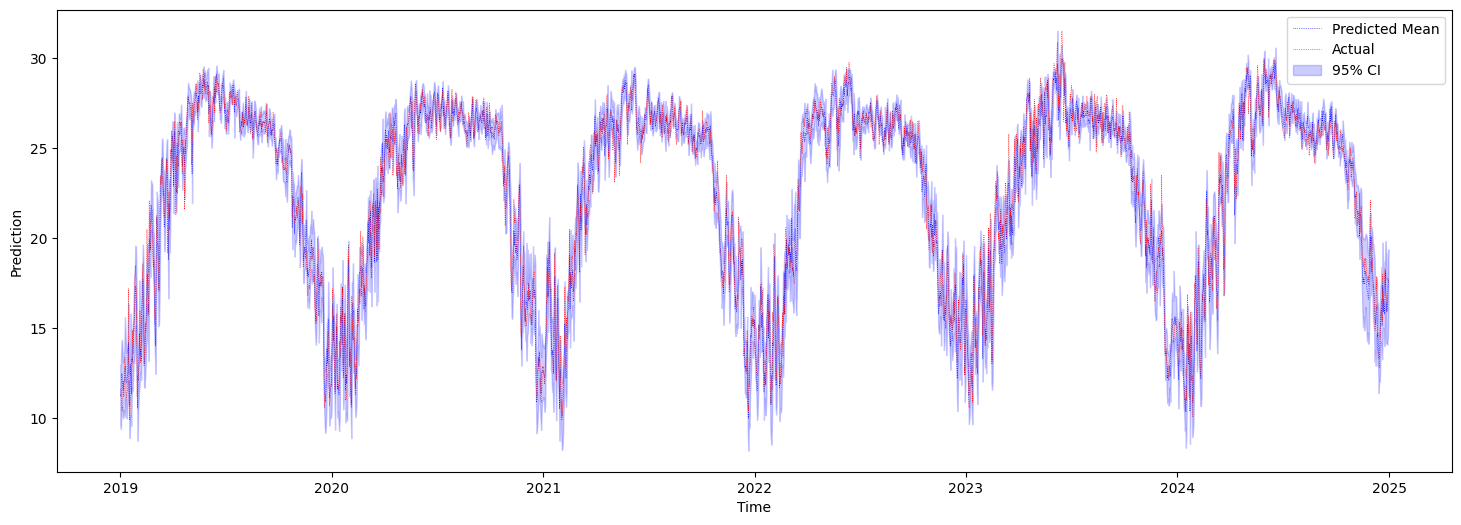

In [37]:
means = pred_gb_mean[:,0]
stds = pred_gb_std[:,0]

#x = np.array(range(len(means)))
x = y_test.index
fig = plt.figure(figsize=(18, 6))
z = norm.ppf(0.975)  # z-score for 95% confidence interval

plt.plot(x, means, color="blue", label="Predicted Mean", linewidth=0.5, linestyle=':')
plt.plot(x,y_test.iloc[:, 0], color="red", label="Actual", linewidth=0.5, linestyle=':')
plt.fill_between(x, means - z*stds, means + z*stds, 
                 color="blue", alpha=0.2, label="95% CI")

#plt.colorbar(label="Density")
plt.xlabel("Time")
plt.ylabel("Prediction")
plt.legend()
plt.show()

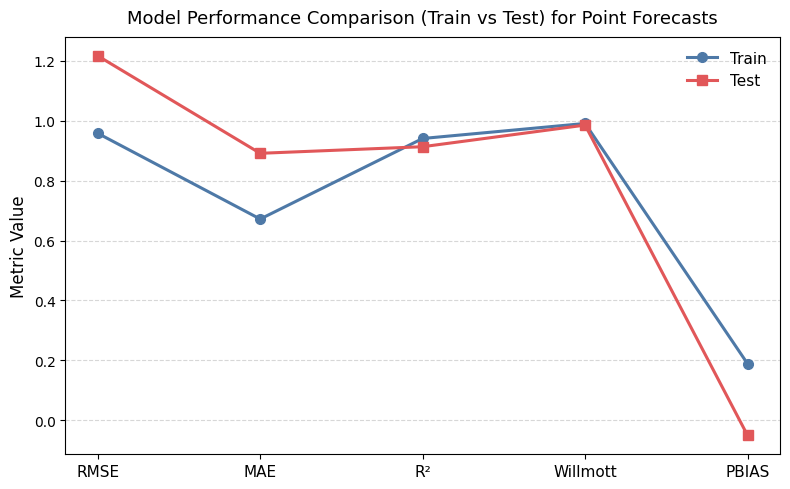

In [38]:
metrics = ['RMSE', 'MAE', 'R²', 'Willmott', 'PBIAS']
train_values = [rmse_point_train, mae_point_train, r2_point_train, willmott_train, pbias_train]
test_values  = [rmse_point, mae_point, r2_point, willmott, pbias]

x = np.arange(len(metrics))

plt.figure(figsize=(8,5))

plt.plot(x, train_values, marker='o', markersize=7, linewidth=2.2, label='Train',
         color='#4E79A7')
plt.plot(x, test_values, marker='s', markersize=7, linewidth=2.2, label='Test',
         color='#E15759')

plt.xticks(x, metrics, fontsize=11)
plt.ylabel('Metric Value', fontsize=12)
plt.title('Model Performance Comparison (Train vs Test) for Point Forecasts', fontsize=13, pad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

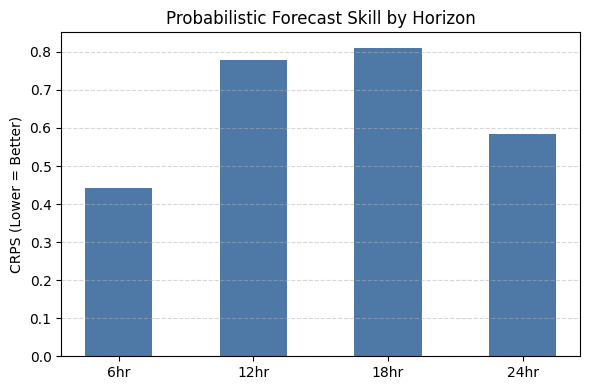

In [39]:
horizons = ['6hr', '12hr', '18hr', '24hr']

plt.figure(figsize=(6,4))
plt.bar(horizons, crps, color='#4E79A7', width=0.5)
plt.ylabel('CRPS (Lower = Better)')
plt.title('Probabilistic Forecast Skill by Horizon')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [40]:
pred_gb_mean_df = pd.DataFrame(pred_gb_mean, index=y_test.index, columns=y_test.columns)
pred_gb_mean_df['Month'] = pred_gb_mean_df.index.month
y_test['Month'] = y_test.index.month

## Interpretation

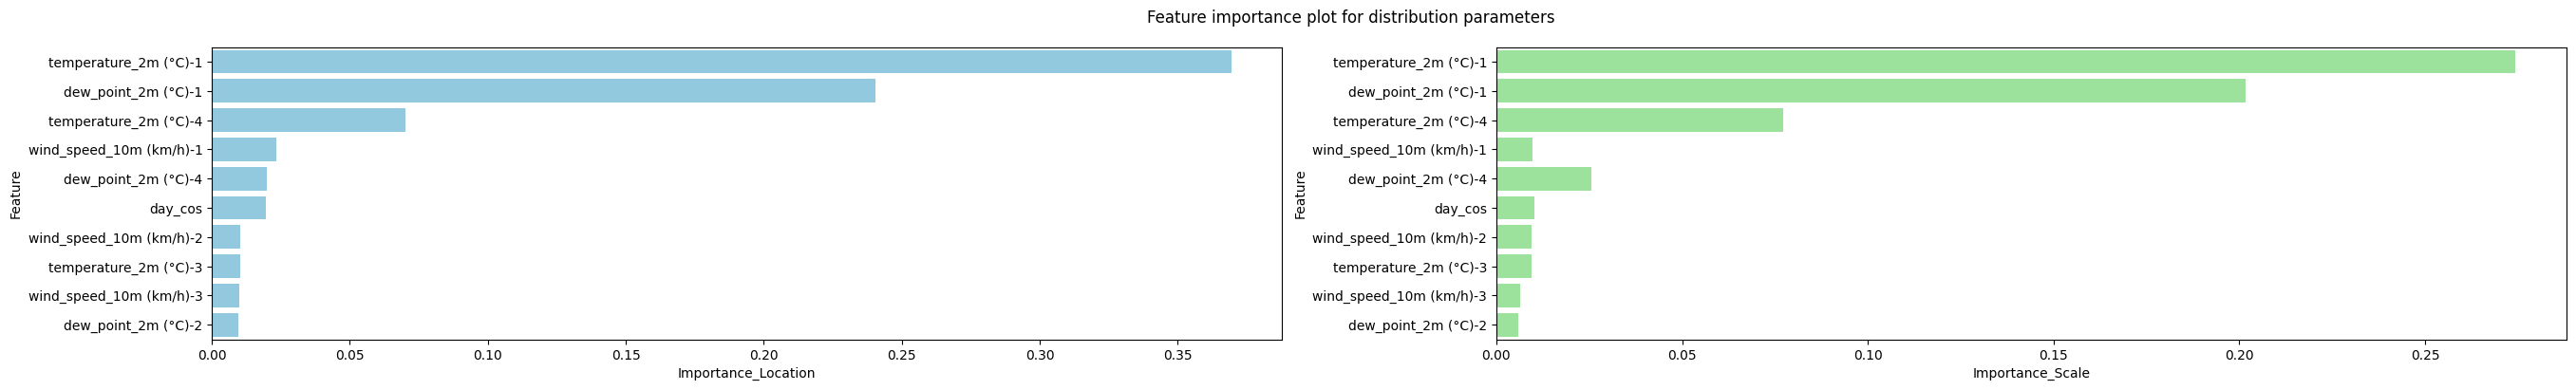

In [41]:
interpret_loc = multi_gb.estimators_[0].feature_importances_[0]
interpret_scale = multi_gb.estimators_[0].feature_importances_[1]
feature_names = X_train.columns
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Location': interpret_loc,
    'Importance_Scale': interpret_scale
})
importances_df = importances_df.sort_values(by='Importance_Location', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(32,4))
fig.suptitle("Feature importance plot for distribution parameters", fontsize=12)
sns.barplot(x='Importance_Location', y='Feature', data=importances_df[:10], ax=ax1, color='skyblue')
sns.barplot(x='Importance_Scale', y='Feature', data=importances_df[:10], ax=ax2, color='lightgreen')
plt.show()

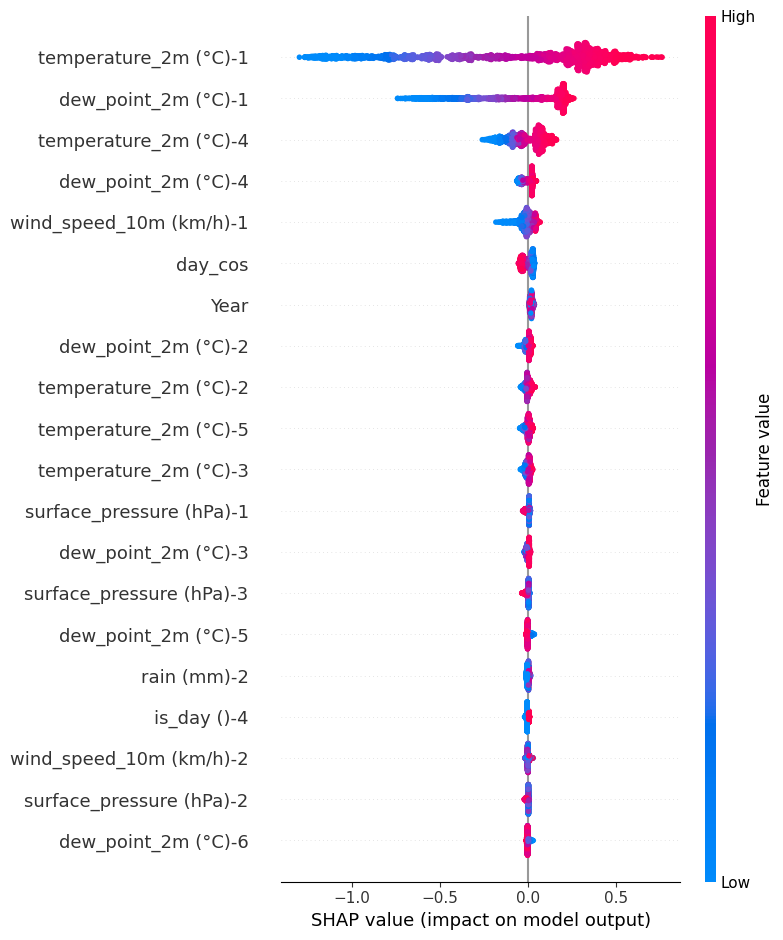

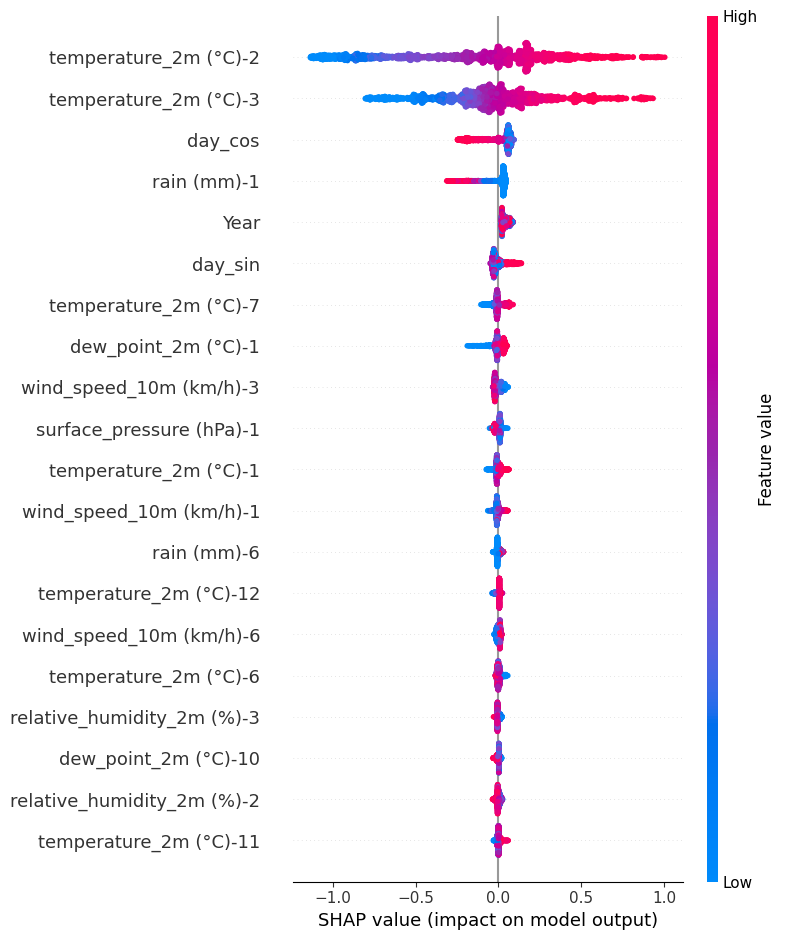

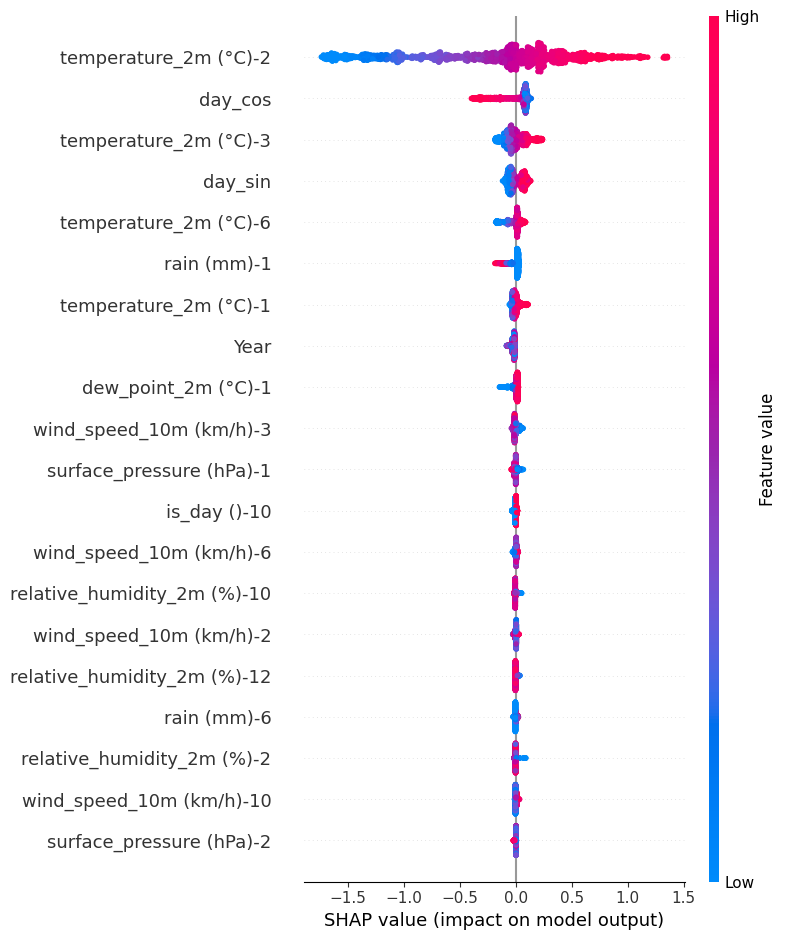

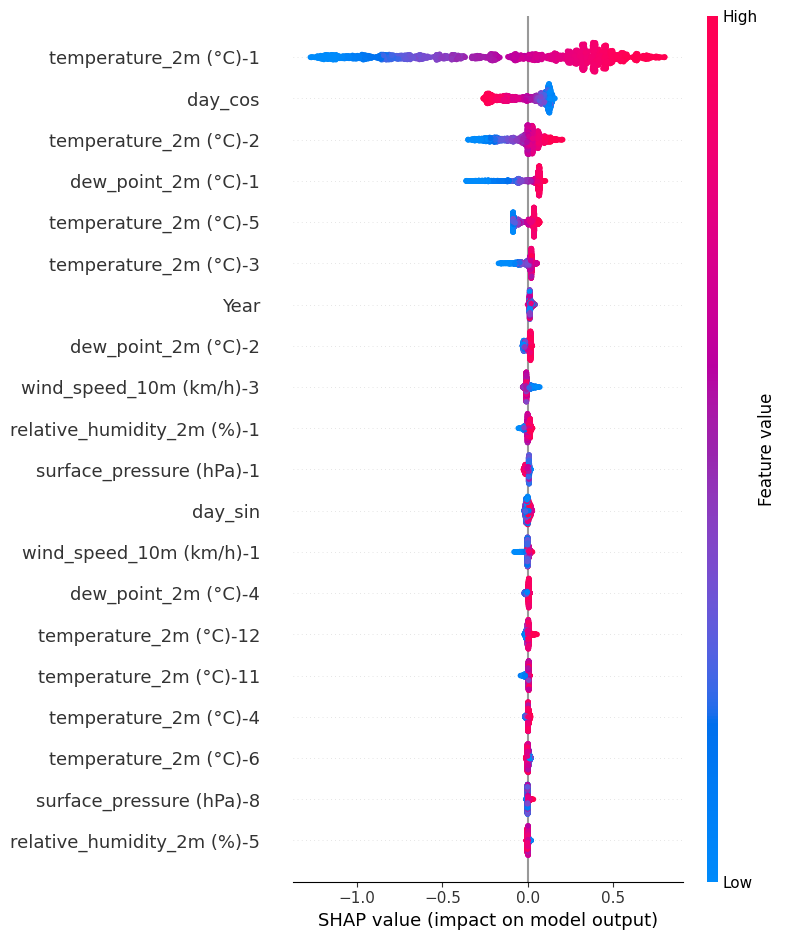

In [42]:
shap.initjs()

explainer = shap.TreeExplainer(multi_gb.estimators_[0], X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X_test.columns)

explainer2 = shap.TreeExplainer(multi_gb.estimators_[1], X_train_scaled)
shap_values = explainer2.shap_values(X_test_scaled, check_additivity=False)
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X_test.columns)

explainer3 = shap.TreeExplainer(multi_gb.estimators_[2], X_train_scaled)
shap_values = explainer3.shap_values(X_test_scaled, check_additivity=False)
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X_test.columns)

explainer4 = shap.TreeExplainer(multi_gb.estimators_[3], X_train_scaled)
shap_values = explainer4.shap_values(X_test_scaled, check_additivity=False)
shap.summary_plot(shap_values, features=X_test_scaled, feature_names=X_test.columns)